# Mekong Delta Hydraulic Analysis - Vinh Chau and Nha Mat
Input of Tung's data June 2025, June 2026. This file is for processing data and creating dataframe, so that the dataframe can be used for analysis of data. 

# Goals of data analysis

1. Overview of offshore and onshore conditions at site
2. Influence of conditions on suspended sediment concentration
3. Influence of bathymetry on conditions (slope, roughness, etc)
4. Influence of interventions on conditions (HOS input)
5. Use relations of hydraulic factor in area to predict what happens during storm conditions

# Setup of dataframe

In [128]:
#import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import welch

In [129]:
#collect data from txt files and convert to pandas dataframe

def read_data(file_path):

    df = pd.read_csv(file_path, sep="\t", comment="#")

    date_col = [col for col in df.columns if col.lower() == "date_time"][0]
    df = df.rename(columns={date_col: "Date_time"})

    df["Date_time"] = pd.to_datetime(
        df["Date_time"],
        format="%d/%m/%Y %H:%M"
    )

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


base_path = Path("/Users/ingeb/repositories/mekong/hydrological_study")

files = {
    2025: {
        "ssc_nearshore": "2025_Data_SSC_Nearshore.txt",
        "ssc_offshore": "2025_Data_SSC_Offshore.txt",
        "water_depth": "2025_Data_WaterDepth.txt",
        "adcp_flow": "2025_Data_Wave_ADCP_TXVC13_Flow.txt",
        "adcp_wave": "2025_Data_Wave_ADCP_TXVC13_Wave.txt",
        "twr_wave": "2025_Data_Wave_TWR2050R.txt",
        "buoy_wave": "2025_Data_Wave_WB2026.txt"
    },

    2026: {
        "water_depth": "2026_Data_WaterDepth.txt",
        "twr_wave": "2026_Data_Wave_TWR2050R.txt",
        "buoy_wave": "2026_Data_Wave_WB2026.txt"
    }
}


data = {
    year: {
        name: read_data(base_path / f"{year}_data" / filename)
        for name, filename in datasets.items()
    }
    for year, datasets in files.items()
}

In [130]:
#check if dataframes are loaded correctly and their shapes
for year in data:

    print(f"\n{year}")

    for name, df in data[year].items():

        print(name, df.shape)


2025
ssc_nearshore (36, 2)
ssc_offshore (47, 2)
water_depth (297, 2)
adcp_flow (165, 3)
adcp_wave (165, 8)
twr_wave (128, 6)
buoy_wave (327, 5)

2026
water_depth (1152, 2)
twr_wave (1152, 6)
buoy_wave (324, 5)


# Table of RAW data provided

In [131]:
def data_summary(data):

    summary = []

    for year, datasets in data.items():
        for name, df in datasets.items():

            for col in df.columns:

                if col == "Date_time":
                    continue

                values = pd.to_numeric(df[col], errors="coerce")

                summary.append({
                    "Year": year,
                    "Dataset": name,
                    "Variable": col,
                    "N": values.count(),
                    "Missing": values.isna().sum(),
                    "Min": values.min(),
                    "Max": values.max(),
                    "Range": values.max() - values.min(),
                    "Mean": values.mean(),
                    "Median": values.median()
                })

    return pd.DataFrame(summary)


raw_summary = data_summary(data)

display(raw_summary.round(3))

,Year,Dataset,Variable,N,Missing,Min,Max,Range,Mean,Median
0,2025,ssc_nearshore,SSC_Near_g_lit,36,0,0.141,0.901,0.760,0.470,0.451
1,2025,ssc_offshore,SSC_Off_g_lit,47,0,0.111,0.886,0.775,0.264,0.208
2,2025,water_depth,water_depth_m,297,0,0.000,0.840,0.840,0.131,0.000
3,2025,adcp_flow,Vel,132,33,0.008,0.850,0.842,0.203,0.187
4,2025,adcp_flow,Dir,132,33,40.000,360.000,320.000,190.409,196.000
5,2025,adcp_wave,Depth,165,0,0.000,3.206,3.206,1.867,2.154
6,2025,adcp_wave,Hs,153,12,0.003,0.948,0.945,0.320,0.293
7,2025,adcp_wave,Tp,153,12,2.000,25.600,23.600,4.513,3.900
8,2025,adcp_wave,Direction,117,48,40.000,360.000,320.000,191.966,199.000
9,2025,adcp_wave,HsSwell,151,14,0.003,0.341,0.338,0.037,0.036


Look at Tung's table for explanation of debreviations. Dir = wave incoming propagation direction relative to true North. DpSwell is propagation direction of swell waves relative to true North.

In [132]:
#data coverage summary from each device deployed, showing start and end data of data collection & number of measurements

coverage = []

for year, datasets in data.items():

    for name, df in datasets.items():

        coverage.append({
            "Year": year,
            "Dataset": name,
            "Start": df["Date_time"].min(),
            "End": df["Date_time"].max(),
            "N": len(df)
        })

coverage = pd.DataFrame(coverage)

display(coverage)

,Year,Dataset,Start,End,N
0,2025,ssc_nearshore,2025-06-12 09:00:00,2025-06-20 18:00:00,36
1,2025,ssc_offshore,2025-06-13 15:00:00,2025-06-20 06:00:00,47
2,2025,water_depth,2025-06-14 10:00:00,2025-06-20 14:00:00,297
3,2025,adcp_flow,2025-06-13 14:00:00,2025-06-20 10:00:00,165
4,2025,adcp_wave,2025-06-13 14:00:00,2025-06-20 10:00:00,165
5,2025,twr_wave,2025-06-12 12:00:00,2025-06-20 10:30:00,128
6,2025,buoy_wave,2025-06-13 14:00:00,2025-06-20 09:00:00,327
7,2026,water_depth,2026-06-22 18:00:00,2026-06-30 17:50:00,1152
8,2026,twr_wave,2026-06-22 18:00:00,2026-06-30 17:50:00,1152
9,2026,buoy_wave,2026-06-23 09:00:00,2026-06-30 09:00:00,324


In [133]:
for year, datasets in data.items():

    for name, df in datasets.items():

        measured_year = df["Date_time"].dt.year.mode()[0]

        assert measured_year == year, (
            f"{name}: expected {year}, "
            f"but data contains {measured_year}"
        )

In [134]:
#makes plot to show all data for the time series of a given variable in a given dataframe
def check_data(df, variable):

    print(df[variable].describe())

    plt.figure(figsize=(12, 4))
    plt.plot(df["Date_time"], df[variable])
    plt.ylabel(variable)
    plt.grid()
    plt.show()

#check_data(data[2025]["buoy_wave"], "Hs")
#check_data(data[2026]["buoy_wave"], "Hs")

# Processing of raw data

In [135]:
rename_columns = {
    "water_depth_m": "Depth",
    "Water_Depth_m": "Depth",
    "Significant wave height": "Hs",
    "Maximum wave height": "H_max",
    "Average wave height": "H_mean",
    "1/10 wave height": "H_10",
    "Wave energy": "Wave_energy",
    "SSC_Near_g_lit": "SSC",
    "SSC_Off_g_lit": "SSC"
}


stations = {
    2025: {
        "water_depth": "VC-NEAR",
        "twr_wave": "VC-NEAR",
        "ssc_nearshore": "VC-NEAR",
        "adcp_wave": "VC-OFF",
        "adcp_flow": "VC-OFF",
        "buoy_wave": "VC-OFF",
        "ssc_offshore": "VC-OFF"
    },

    2026: {
        "water_depth": "VC-TWR",
        "twr_wave": "VC-TWR",
        "buoy_wave": "VC-BUOY-S"
    }
}


processed = {}

for year, datasets in data.items():

    processed[year] = {}

    for name, df in datasets.items():

        df = df.rename(columns=rename_columns).copy()

        df["Station"] = stations[year][name]
        df["Campaign"] = year

        processed[year][name] = df

In [136]:
#instrument/ QA info from hydro file Tung

#Zero depth means the intertidal mudflat was exposed during low tide
#Measurements with near-zero wave height and water depth ≤0.05 m are flagged as likely sensor exposure.
#When the nearshore pressure sensor is exposed, wave statistics fall to approximately Hs=0.001
#Outliers were flagged in the doc provided by Tung, removed from data processing

# 2025 intertidal exposure issues
processed[2025]["water_depth"]["exposed"] = (
    processed[2025]["water_depth"]["Depth"] == 0
)

processed[2025]["twr_wave"]["dry_or_exposed"] = (
    (processed[2025]["twr_wave"]["Depth"] <= 0.05)
    | (processed[2025]["twr_wave"]["Hs"] <= 0.001)
)


# Known wave-buoy outliers from metadata
bad_times = {
    2025: pd.to_datetime([
        "13/06/2025 14:00",
        "18/06/2025 14:00",

        # Additional extreme end-of-record buoy spikes
        "20/06/2025 08:30",
        "20/06/2025 09:00"
    ], dayfirst=True),

    2026: pd.to_datetime([
        "23/06/2026 09:00"
    ], dayfirst=True)
}

for year in [2025, 2026]:

    processed[year]["buoy_wave"]["QA_outlier"] = (
        processed[year]["buoy_wave"]["Date_time"]
        .isin(bad_times[year])
    )

# Wave calculations
p = 1025 kg/m3 --> seawater density,
E = pgHs2/16 --> standard wave-energy estimate

In [138]:
g = 9.81
rho = 1025

#dispersion relation for linear waves, used to calculate wave number from wave period and water depth. The function uses the Newton-Raphson method to iteratively solve for the wave number k given the wave period T and water depth h. The function returns NaN if T or h are NaN or non-positive.
def wave_number(T, h):

    if pd.isna(T) or pd.isna(h) or T <= 0 or h <= 0:
        return np.nan

    omega = 2*np.pi / T
    k = omega**2 / g

    for _ in range(50):
        kh = k*h
        f = g*k*np.tanh(kh) - omega**2
        df = g*(np.tanh(kh) + kh/np.cosh(kh)**2)

        k_new = k - f/df

        if abs(k_new - k) < 1e-10:
            break

        k = k_new

    return k


# function to add wave parameters to a dataframe containing wave data. The function calculates wave number, wavelength, wave regime, phase speed, group speed, wave energy, wave power, steepness, and bed orbital velocity based on the input dataframe and specified depth column. The function returns a new dataframe with the added parameters.
def add_wave_parameters(df, depth_col="Depth"):

    df = df.copy()

    df["k"] = [
        wave_number(T, h)
        for T, h in zip(df["Tp"], df[depth_col])
    ]

    df["L"] = 2*np.pi / df["k"]
    df["kh"] = df["k"] * df[depth_col]
    df["h_L"] = df[depth_col] / df["L"]

    df["wave_regime"] = pd.cut(
        df["h_L"],
        [-np.inf, 1/20, 1/2, np.inf],
        labels=["shallow", "intermediate", "deep"]
    )

    omega = 2*np.pi / df["Tp"]

    df["C"] = omega / df["k"]
    df["n"] = 0.5 * (1 + 2*df["kh"]/np.sinh(2*df["kh"]))
    df["Cg"] = df["n"] * df["C"]

    df["E"] = rho*g*df["Hs"]**2 / 16
    df["P"] = df["E"] * df["Cg"]

    df["steepness"] = df["Hs"] / df["L"]
    df["Hs_h"] = df["Hs"] / df[depth_col]

    df["U_bed"] = (
        np.pi*df["Hs"]
        / (df["Tp"] * np.sinh(df["kh"]))
    )

    return df

In [139]:
# Add wave parameters to 2025 TWr and ADCP wave data, which already have Hs, Tp and Depth. 

processed[2025]["twr_wave"] = add_wave_parameters(
    processed[2025]["twr_wave"]
)

processed[2025]["adcp_wave"] = add_wave_parameters(
    processed[2025]["adcp_wave"]
)

In [140]:
# Add wave parameters to 2025 Buoy, which has Hs and Tp.
# 2025 buoy has no depth.
# Assumption: use nearest ADCP depth because both instruments are at VC-OFF.

buoy_2025 = processed[2025]["buoy_wave"].copy()

adcp_depth = processed[2025]["adcp_wave"][
    ["Date_time", "Depth"]
]

buoy_2025 = pd.merge_asof(
    buoy_2025.sort_values("Date_time"),
    adcp_depth.sort_values("Date_time"),
    on="Date_time",
    direction="nearest",
    tolerance=pd.Timedelta("30min")
)

processed[2025]["buoy_wave_depth"] = add_wave_parameters(
    buoy_2025
)

2026 wave calculations cannot currently use the dispersion relation:

VC-TWR:
- Water depth and wave heights are available, but Tp is not provided.
- Without wave period, omega and therefore k cannot be calculated.

VC-BUOY-S:
- Hs and Tp are available, but no local water depth is provided.
- VC-TWR depth should NOT be used because VC-TWR and VC-BUOY-S are different locations.

Therefore dispersion-based wavelength, C, Cg and wave power are not calculated for the 2026 datasets unless additional Tp or local depth data becomes available.

In [157]:
wave_data = {
    "VC-NEAR TWR": processed[2025]["twr_wave"].loc[
        ~processed[2025]["twr_wave"]["dry_or_exposed"]
    ],

    "VC-OFF ADCP": processed[2025]["adcp_wave"].loc[
        processed[2025]["adcp_wave"]["Depth"] >= 0.35
    ],

    "VC-OFF Buoy": processed[2025]["buoy_wave_depth"].loc[
        ~processed[2025]["buoy_wave_depth"]["QA_outlier"]
    ]
}

summary = []

for name, df in wave_data.items():

    summary.append({
        "Dataset": name,
        "Hs_mean": df["Hs"].mean(),
        "Hs_max": df["Hs"].max(),
        "Tp_mean": df["Tp"].mean(),
        "Depth_mean": df["Depth"].mean(),
        "L_mean": df["L"].mean(),
        "Cg_mean": df["Cg"].mean(),
        "P_mean": df["P"].mean(),
        "U_bed_mean": df["U_bed"].mean()
    })

wave_summary = pd.DataFrame(summary)

display(wave_summary.round(3))

,Dataset,Hs_mean,Hs_max,Tp_mean,Depth_mean,L_mean,Cg_mean,P_mean,U_bed_mean
0,VC-NEAR TWR,0.08,0.419,2.230,0.456,4.435,1.685,18.964,0.133
1,VC-OFF ADCP,0.33,0.948,4.321,2.141,17.411,3.224,280.457,0.285
2,VC-OFF Buoy,0.38,5.133,4.224,1.885,15.016,2.985,551.850,0.794


In [158]:
for name, df in wave_data.items():

    print("\n", name)
    display(df["wave_regime"].value_counts())


 VC-NEAR TWR


wave_regime
intermediate    43
shallow          0
deep             0
Name: count, dtype: int64


 VC-OFF ADCP


wave_regime
intermediate    132
shallow           8
deep              0
Name: count, dtype: int64


 VC-OFF Buoy


wave_regime
intermediate    277
shallow          42
deep              0
Name: count, dtype: int64

None of the measurements collected fall within deep water regime. 

# Combine measured and calculated data

In [152]:
# Merging datasets based on which time stamp is nearest. The datasets are conducted in the same campaign, but have different timestamps because they have different measurement frequencies. This allows the data to be compared by matching nearest timestaps.
# The dataset with the least measurements is used as the backbone, and the other dataset is merged to it. The tolerance is set to 1 hour, meaning that if the nearest timestamp is more than 1 hour away, it will not be merged.
def merge_nearest(left, right, tolerance="1h"):

    return pd.merge_asof(                   #merge_as(of) is a function that finds the closest measurement, which is in this case time. 
        left.sort_values("Date_time"),
        right.sort_values("Date_time"),
        on="Date_time",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance)
    )

#nearshore 2025 data
ssc_near = processed[2025]["ssc_nearshore"][
    ["Date_time", "SSC"]
].copy()

twr_near = processed[2025]["twr_wave"][
    ["Date_time", "Depth", "Hs", "Tp",
     "U_bed", "P", "L", "Cg", "steepness", "Hs_h",
     "dry_or_exposed"]
].rename(columns={"Depth": "TWR_depth"})

water_near = processed[2025]["water_depth"][
    ["Date_time", "Depth"]
].rename(columns={"Depth": "Water_depth"})

near_2025_ssc = merge_nearest(ssc_near, twr_near)
near_2025_ssc = merge_nearest(near_2025_ssc, water_near)

#offshore 2025 data
adcp_wave = processed[2025]["adcp_wave"][
    ["Date_time", "Depth", "Hs", "Tp", "Direction",
     "HsSwell", "TpSwell", "DpSwell",
     "U_bed", "P", "L", "Cg", "steepness", "Hs_h"]
].rename(columns={"Direction": "Wave_direction"})

adcp_flow = processed[2025]["adcp_flow"][
    ["Date_time", "Vel", "Dir"]
].rename(columns={
    "Vel": "Current_velocity",
    "Dir": "Current_direction"
})

ssc_off = processed[2025]["ssc_offshore"][
    ["Date_time", "SSC"]
]

# ADCP wave and current data have the same hourly timestamps
off_2025 = pd.merge(
    adcp_wave,
    adcp_flow,
    on="Date_time",
    how="outer"
)

# ADCP measurements may be unreliable below ~0.35 m water depth, Tung instructions
off_2025["low_depth_flag"] = off_2025["Depth"] < 0.35

off_2025_ssc = merge_nearest(ssc_off, off_2025)

# VC-TWR 2026 data
#2026 VC-TWR data, water depth and wave data both every 10 minutes, can be joined directly
near_2026 = pd.merge(
    processed[2026]["water_depth"][["Date_time", "Depth"]],
    processed[2026]["twr_wave"],
    on="Date_time",
    how="inner"
)

In [ ]:
# Nearshore: exclude dry/exposed TWR measurements
near_ssc_valid = near_2025_ssc.loc[
    (near_2025_ssc["dry_or_exposed"] == False)
    & (near_2025_ssc["Water_depth"] > 0)
].copy()

# Offshore: exclude ADCP measurements below reliable depth
off_ssc_valid = off_2025_ssc.loc[
    off_2025_ssc["Depth"] >= 0.35
].copy()

# Offshore hydrodynamic data
off_2025_valid = off_2025.loc[
    off_2025["Depth"] >= 0.35
].copy()

# Plotting section (quick check of parameters, fill in yourself)

count    327.000000
mean       0.478939
std        1.069614
min        0.114000
25%        0.248500
50%        0.308000
75%        0.419500
max       13.889000
Name: Hs, dtype: float64


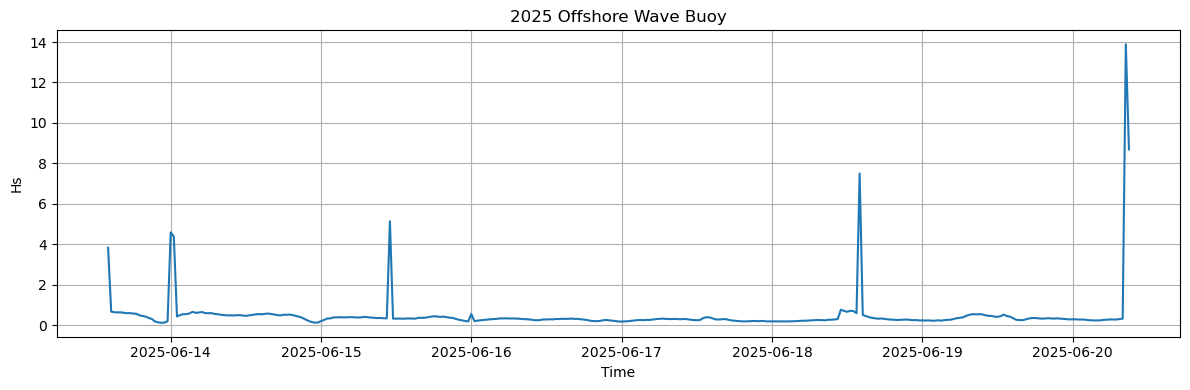

count    128.000000
mean       0.027625
std        0.064459
min        0.001000
25%        0.001000
50%        0.001000
75%        0.006250
max        0.419000
Name: Hs, dtype: float64


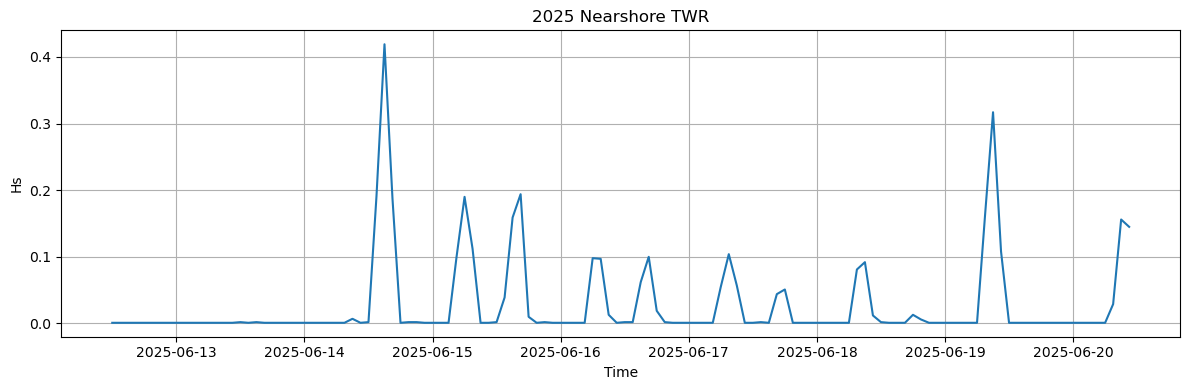

count    153.000000
mean       0.320026
std        0.150532
min        0.003000
25%        0.241000
50%        0.293000
75%        0.400000
max        0.948000
Name: Hs, dtype: float64


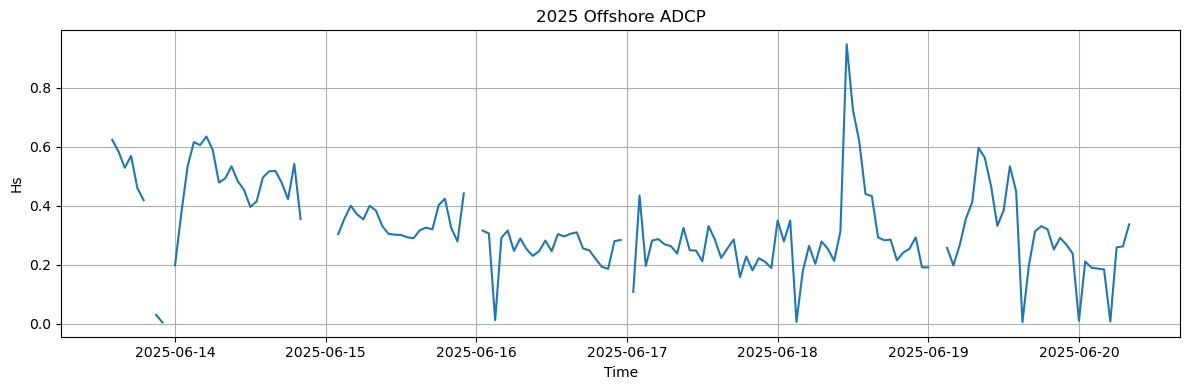

In [143]:
def quick_plot(df, variable, title=""):

    print(df[variable].describe())

    plt.figure(figsize=(12, 4))
    plt.plot(df["Date_time"], df[variable])

    plt.xlabel("Time")
    plt.ylabel(variable)
    plt.title(title)
    plt.grid()

    plt.tight_layout()
    plt.show()

quick_plot(
    processed[2025]["buoy_wave"], 
    "Hs", 
    "2025 Offshore Wave Buoy"
)

quick_plot(
    processed[2025]["twr_wave"], 
    "Hs", 
    "2025 Nearshore TWR"
)

quick_plot(
    processed[2025]["adcp_wave"], 
    "Hs", 
    "2025 Offshore ADCP"
)


# Nearshore vs Offshore

In [ ]:
near_wave = processed[2025]["twr_wave"].loc[
    ~processed[2025]["twr_wave"]["dry_or_exposed"],
    ["Date_time", "Hs"]
].rename(columns={"Hs": "Hs_near"})


off_wave = processed[2025]["buoy_wave"].loc[
    ~processed[2025]["buoy_wave"]["QA_outlier"],
    ["Date_time", "Hs"]
].rename(columns={"Hs": "Hs_off"})


#merge the nearshore and offshore wave data based on nearest timestamps, with a tolerance of 45 minutes. 
#tolerance is 45 because the TWR measurements occur every 90 minutes
wave_compare_2025 = merge_nearest(
    near_wave,
    off_wave,
    tolerance="45min"
)

wave_compare_2025["Hs_ratio"] = (
    wave_compare_2025["Hs_near"]
    / wave_compare_2025["Hs_off"]
)

wave_compare_2025["Energy_ratio"] = (
    wave_compare_2025["Hs_ratio"]**2
)

# statistics

wave_compare_valid = wave_compare_2025.dropna(
    subset=["Hs_near", "Hs_off"]
).copy()

wave_compare_valid["Hs_reduction_%"] = (
    1 - wave_compare_valid["Hs_ratio"]
) * 100

transformation_summary = wave_compare_valid[
    ["Hs_ratio", "Energy_ratio", "Hs_reduction_%"]
].agg(["mean", "median", "min", "max"]).T

display(transformation_summary.round(3))



,mean,median,min,max
Hs_ratio,0.199,0.179,0.003,0.759
Energy_ratio,0.077,0.032,0.000,0.576
Hs_reduction_%,80.116,82.085,24.094,99.697


# Site Conditions Table

In [165]:
# Overview of site conditions
# Values are shown as range (mean)

def stat(df, col):

    if col not in df.columns:
        return "—"

    x = df[col].dropna()

    if len(x) == 0:
        return "—"

    return f"{x.min():.2f}–{x.max():.2f} ({x.mean():.2f})"


conditions_summary = pd.DataFrame([
    {
        "Campaign / station": "2025 VC-NEAR",
        "Depth [m]": stat(processed[2025]["water_depth"], "Depth"),
        "Hs [m]": stat(wave_data["VC-NEAR TWR"], "Hs"),
        "Tp [s]": stat(wave_data["VC-NEAR TWR"], "Tp"),
        "Current [m/s]": "—",
        "U_bed [m/s]": stat(wave_data["VC-NEAR TWR"], "U_bed"),
        "P [W/m]": stat(wave_data["VC-NEAR TWR"], "P")
    },

    {
        "Campaign / station": "2025 VC-OFF",
        "Depth [m]": stat(off_2025_valid, "Depth"),
        "Hs [m]": stat(wave_data["VC-OFF ADCP"], "Hs"),
        "Tp [s]": stat(wave_data["VC-OFF ADCP"], "Tp"),
        "Current [m/s]": stat(off_2025_valid, "Current_velocity"),
        "U_bed [m/s]": stat(wave_data["VC-OFF ADCP"], "U_bed"),
        "P [W/m]": stat(wave_data["VC-OFF ADCP"], "P")
    },

    {
        "Campaign / station": "2026 VC-TWR",
        "Depth [m]": stat(processed[2026]["water_depth"], "Depth"),
        "Hs [m]": stat(processed[2026]["twr_wave"], "Hs"),
        "Tp [s]": "—",
        "Current [m/s]": "—",
        "U_bed [m/s]": "—",
        "P [W/m]": "—"
    },

    {
        "Campaign / station": "2026 VC-BUOY-S",
        "Depth [m]": "—",
        "Hs [m]": stat(
            processed[2026]["buoy_wave"].loc[
                ~processed[2026]["buoy_wave"]["QA_outlier"]
            ],
            "Hs"
        ),
        "Tp [s]": stat(
            processed[2026]["buoy_wave"].loc[
                ~processed[2026]["buoy_wave"]["QA_outlier"]
            ],
            "Tp"
        ),
        "Current [m/s]": "—",
        "U_bed [m/s]": "—",
        "P [W/m]": "—"
    }
])

display(conditions_summary)

,Campaign / station,Depth [m],Hs [m],Tp [s],Current [m/s],U_bed [m/s],P [W/m]
0,2025 VC-NEAR,0.00–0.84 (0.13),0.00–0.42 (0.08),1.57–2.96 (2.23),—,0.01–0.55 (0.13),0.00–236.20 (18.96)
1,2025 VC-OFF,0.35–3.21 (2.14),0.01–0.95 (0.33),2.50–25.60 (4.32),0.01–0.85 (0.20),0.01–0.73 (0.29),0.06–1841.15 (280.46)
2,2026 VC-TWR,0.82–2.37 (1.43),0.00–0.40 (0.06),—,—,—,—
3,2026 VC-BUOY-S,—,0.53–4.66 (0.80),3.09–6.83 (4.88),—,—,—


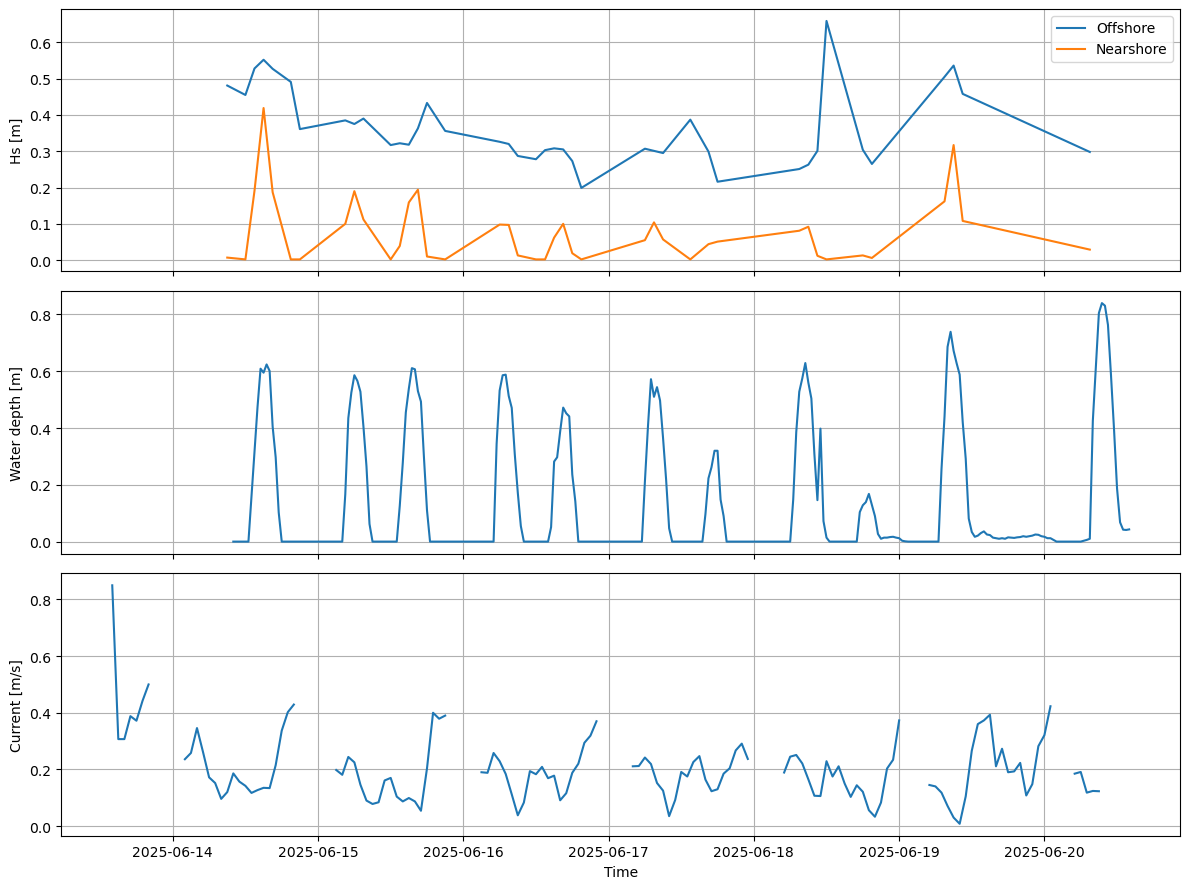

In [166]:
# 2025 hydrodynamic overview

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Waves
axes[0].plot(
    wave_compare_valid["Date_time"],
    wave_compare_valid["Hs_off"],
    label="Offshore"
)

axes[0].plot(
    wave_compare_valid["Date_time"],
    wave_compare_valid["Hs_near"],
    label="Nearshore"
)

axes[0].set_ylabel("Hs [m]")
axes[0].legend()
axes[0].grid()


# Nearshore water depth
axes[1].plot(
    processed[2025]["water_depth"]["Date_time"],
    processed[2025]["water_depth"]["Depth"]
)

axes[1].set_ylabel("Water depth [m]")
axes[1].grid()


# Offshore current
axes[2].plot(
    processed[2025]["adcp_flow"]["Date_time"],
    processed[2025]["adcp_flow"]["Vel"]
)

axes[2].set_ylabel("Current [m/s]")
axes[2].set_xlabel("Time")
axes[2].grid()

plt.tight_layout()
plt.show()

# SSC Relationships

In [ ]:
# Are larger waves associated with higher SSC?
# Scc vs Hs, Tp, depth, and U_bed for nearshore and offshore, offshore also current velocity

def plot_ssc_relationships(df, variables, labels, location):

    fig, axes = plt.subplots(1, len(variables), figsize=(15, 4))

    for ax, variable, label in zip(axes, variables, labels):

        ax.scatter(df[variable], df["SSC"])
        ax.set_xlabel(label)
        ax.set_ylabel("SSC [g/L]")
        ax.set_title(f"{location}: SSC vs {label}")
        ax.grid()

    plt.tight_layout()
    plt.show()


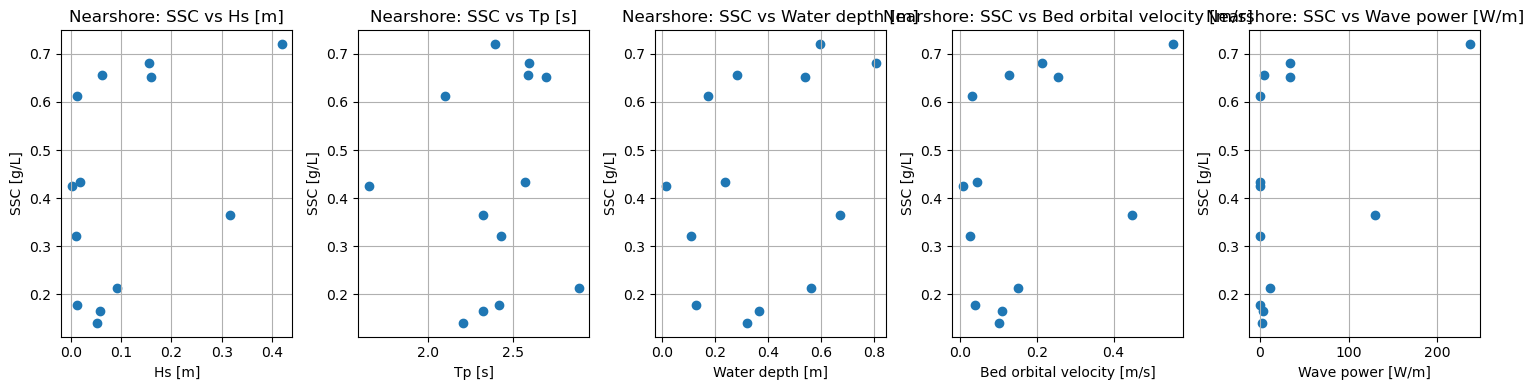

In [169]:
# Nearshore SSC relationships

plot_ssc_relationships(
    near_ssc_valid,
    ["Hs", "Tp", "Water_depth", "U_bed", "P"],
    ["Hs [m]",
     "Tp [s]",
     "Water depth [m]",
     "Bed orbital velocity [m/s]",
     "Wave power [W/m]"],
    "Nearshore"
)

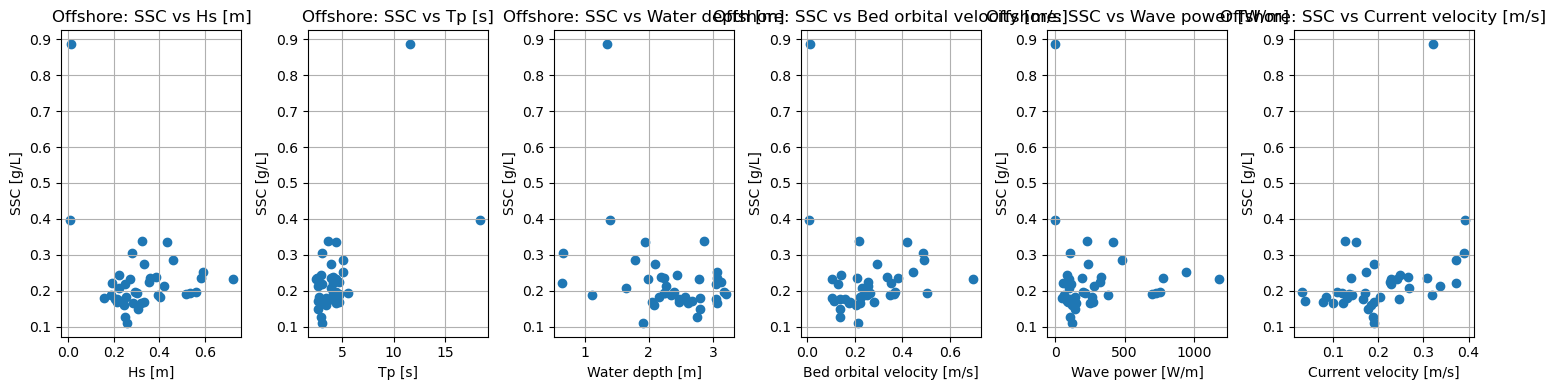

In [170]:
# Offshore SSC relationships

plot_ssc_relationships(
    off_ssc_valid,
    ["Hs", "Tp", "Depth", "U_bed", "P", "Current_velocity"],
    ["Hs [m]",
     "Tp [s]",
     "Water depth [m]",
     "Bed orbital velocity [m/s]",
     "Wave power [W/m]",
     "Current velocity [m/s]"],
    "Offshore"
)

In [173]:
# Correlations

near_corr = near_2025_ssc[
    ["SSC", "Hs", "Tp", "Water_depth", "U_bed", "P"]
].corr()

off_corr = off_2025_ssc[
    ["SSC", "Hs", "Tp", "Depth", "U_bed", "P", "Current_velocity"]
].corr()


print("Nearshore")
display(near_corr.round(2))

print("Offshore")
display(off_corr.round(2))

Nearshore


,SSC,Hs,Tp,Water_depth,U_bed,P
SSC,1.00,0.14,0.06,0.29,0.15,0.18
Hs,0.14,1.00,0.38,0.81,0.99,0.95
Tp,0.06,0.38,1.00,0.78,0.49,0.23
Water_depth,0.29,0.81,0.78,1.00,0.84,0.61
U_bed,0.15,0.99,0.49,0.84,1.00,0.92
P,0.18,0.95,0.23,0.61,0.92,1.00


Offshore


,SSC,Hs,Tp,Depth,U_bed,P,Current_velocity
SSC,1.00,-0.47,0.70,-0.54,0.08,-0.22,0.38
Hs,-0.47,1.00,-0.43,0.47,0.25,0.91,-0.23
Tp,0.70,-0.43,1.00,-0.40,-0.19,-0.14,0.34
Depth,-0.54,0.47,-0.40,1.00,-0.45,0.39,-0.63
U_bed,0.08,0.25,-0.19,-0.45,1.00,0.19,0.05
P,-0.22,0.91,-0.14,0.39,0.19,1.00,-0.17
Current_velocity,0.38,-0.23,0.34,-0.63,0.05,-0.17,1.00


In [174]:
# SSC relationship summary, correlation also compared with Spearman

def relation_table(df, variables, location):

    results = []

    for var in variables:

        pair = df[["SSC", var]].dropna()

        results.append({
            "Location": location,
            "Variable": var,
            "N": len(pair),
            "Pearson": pair["SSC"].corr(pair[var]),
            "Spearman": pair["SSC"].corr(pair[var], method="spearman")
        })

    return pd.DataFrame(results)


ssc_relations = pd.concat([
    relation_table(
        near_ssc_valid,
        ["Hs", "Tp", "Water_depth", "U_bed", "P"],
        "Nearshore"
    ),

    relation_table(
        off_ssc_valid,
        ["Hs", "Tp", "Depth", "U_bed", "P", "Current_velocity"],
        "Offshore"
    )
], ignore_index=True)


display(ssc_relations.round(3))

,Location,Variable,N,Pearson,Spearman
0,Nearshore,Hs,13,0.419,0.424
1,Nearshore,Tp,13,0.094,0.286
2,Nearshore,Water_depth,13,0.318,0.302
3,Nearshore,U_bed,13,0.405,0.407
4,Nearshore,P,13,0.406,0.440
5,Offshore,Hs,40,-0.277,0.205
6,Offshore,Tp,40,0.613,0.305
7,Offshore,Depth,40,-0.353,-0.261
8,Offshore,U_bed,40,-0.148,0.294
9,Offshore,P,40,-0.084,0.141


In [177]:
# Determine rising/falling tide from water-depth change
# Assumption: positive depth change = rising tide, negative = falling tide.

near_tide = processed[2025]["water_depth"][
    ["Date_time", "Depth"]
].dropna().sort_values("Date_time").copy()

near_tide["Tide_stage"] = np.where(
    near_tide["Depth"].diff() >= 0,
    "Rising",
    "Falling"
)


off_tide = processed[2025]["adcp_wave"][
    ["Date_time", "Depth"]
].dropna().sort_values("Date_time").copy()

off_tide["Tide_stage"] = np.where(
    off_tide["Depth"].diff() >= 0,
    "Rising",
    "Falling"
)


near_ssc_valid = merge_nearest(
    near_ssc_valid,
    near_tide[["Date_time", "Tide_stage"]],
    tolerance="30min"
)

off_ssc_valid = merge_nearest(
    off_ssc_valid,
    off_tide[["Date_time", "Tide_stage"]],
    tolerance="1h"
)

In [178]:
# SSC during rising and falling tide

tidal_ssc = pd.concat([
    near_ssc_valid.assign(Location="Nearshore"),
    off_ssc_valid.assign(Location="Offshore")
])

tidal_ssc_summary = (
    tidal_ssc
    .groupby(["Location", "Tide_stage"])["SSC"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(tidal_ssc_summary.round(3))

count   mean  median    min    max
Location  Tide_stage                                    
Nearshore Falling         8  0.408   0.396  0.166  0.720
          Rising          5  0.461   0.651  0.141  0.681
Offshore  Falling        23  0.247   0.198  0.128  0.886
          Rising         17  0.208   0.196  0.111  0.336

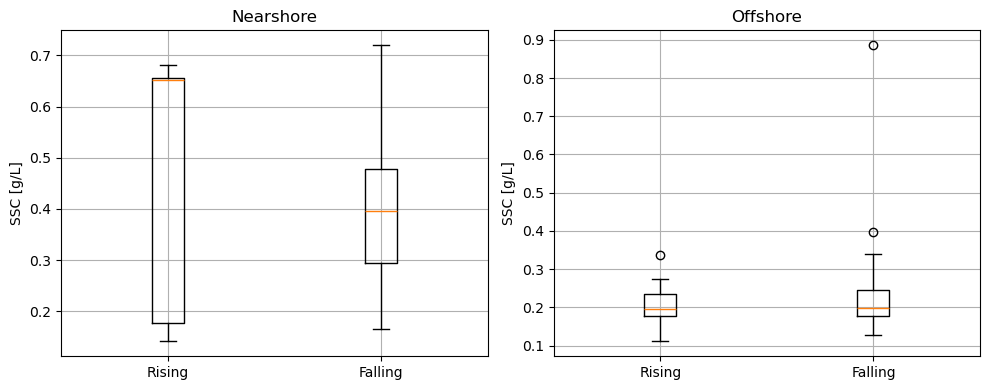

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (location, df) in zip(
    axes,
    [
        ("Nearshore", near_ssc_valid),
        ("Offshore", off_ssc_valid)
    ]
):

    rising = df.loc[df["Tide_stage"] == "Rising", "SSC"].dropna()
    falling = df.loc[df["Tide_stage"] == "Falling", "SSC"].dropna()

    ax.boxplot(
        [rising, falling],
        tick_labels=["Rising", "Falling"]
    )

    ax.set_title(location)
    ax.set_ylabel("SSC [g/L]")
    ax.grid()

plt.tight_layout()
plt.show()

# Tidal analysis - Welch Spectrum
This is mostly useful for tidal analysis, not so much for constructing a spectrum of the frequencies of waves in the area. This is because the sensors have a nyquist frequency that is too low to pick up the actual spectrum. Can find tides, but since the data colletion is only conducted for a week, it will not pick up on long term seaonal trends

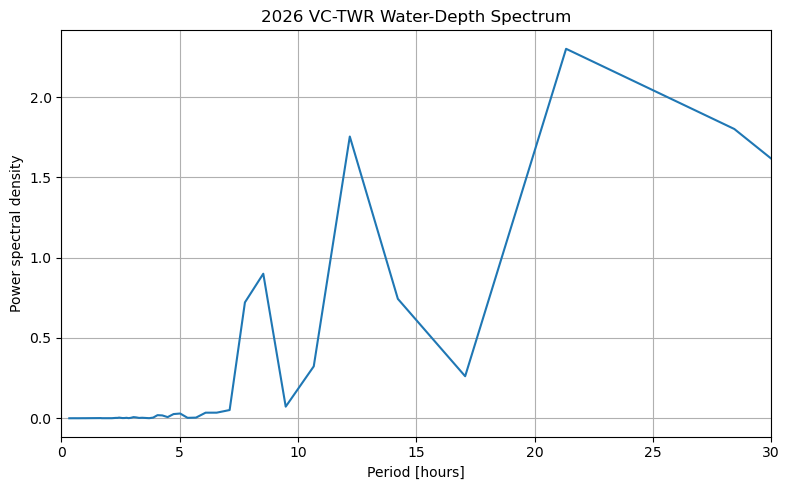

In [149]:
water = (
    processed[2026]["water_depth"]
    .dropna(subset=["Depth"])
    .sort_values("Date_time")
)

depth = water["Depth"].to_numpy()

# Determine sampling interval from the data
dt_seconds = (
    water["Date_time"]
    .diff()
    .dt.total_seconds()
    .median()
)

# Sampling frequency in measurements per hour
fs = 3600 / dt_seconds


# Welch power spectrum --> the 512 measurement per Welch segment can be altered. 
f, Pxx = welch(
    depth,
    fs=fs,
    nperseg=min(512, len(depth)),
    detrend="constant"
)


mask = f > 0
f = f[mask]
Pxx = Pxx[mask]

period_hours = 1 / f

order = np.argsort(period_hours)

period_hours = period_hours[order]
Pxx = Pxx[order]


plt.figure(figsize=(8, 5))

plt.plot(period_hours, Pxx)

plt.xlabel("Period [hours]")
plt.ylabel("Power spectral density")
plt.title("2026 VC-TWR Water-Depth Spectrum")

plt.xlim(0, 30)
plt.grid()

plt.tight_layout()
plt.show()

Analysis: 
- Peak around 12-13 hours = sedmidiurnal scale variability
- Peak around 24 hours = daily-scale variation 

This is the dominant pattern during this campaign, but not a complete tidal analysis the year

# Assumption Check!

In [ ]:
# assumption check of data linkage

data_links = pd.DataFrame([
    # 2025 NEARSHORE
    ["2025", "VC-NEAR", "SSC + waves",
     "SSC nearshore", "TWR wave",
     "Nearest timestamp, max 1 h",
     "Wave conditions are assumed representative of the SSC sample time."],

    ["2025", "VC-NEAR", "SSC + water depth",
     "SSC nearshore", "Diver water depth",
     "Nearest timestamp, max 1 h",
     "Water depth is assumed representative of the SSC sample time."],

    ["2025", "VC-NEAR", "Wave calculations",
     "TWR Hs + Tp", "TWR Depth",
     "Same measurement record",
     "Depth, Hs and Tp are measured by the same instrument; no cross-dataset depth assumption."],

    # 2025 OFFSHORE
    ["2025", "VC-OFF", "Waves + currents",
     "ADCP wave", "ADCP flow",
     "Same timestamp",
     "Both datasets are from the same station and hourly measurement grid."],

    ["2025", "VC-OFF", "SSC + hydrodynamics",
     "SSC offshore", "ADCP wave + flow",
     "Nearest timestamp, max 1 h",
     "Hydrodynamic conditions are assumed representative of the SSC sample time."],

    ["2025", "VC-OFF", "ADCP wave calculations",
     "ADCP Hs + Tp", "ADCP Depth",
     "Same measurement record",
     "Depth, Hs and Tp are measured by the same instrument."],

    ["2025", "VC-OFF", "Buoy wave calculations",
     "Buoy Hs + Tp", "ADCP Depth",
     "Nearest timestamp, max 30 min",
     "Buoy has no depth. ADCP depth is used because both instruments are at VC-OFF."],

    # NEARSHORE/OFFSHORE COMPARISON
    ["2025", "VC-NEAR ↔ VC-OFF", "Hs comparison",
     "TWR nearshore Hs", "Buoy offshore Hs",
     "Nearest timestamp, max 45 min",
     "Dry nearshore records and flagged buoy outliers are excluded."],

    # 2026
    ["2026", "VC-TWR", "Depth + wave statistics",
     "TWR water depth", "TWR wave data",
     "Exact 10-min timestamp",
     "Same station and sampling interval; no time-matching assumption."],

    ["2026", "VC-TWR", "Dispersion relation",
     "TWR wave data", "TWR depth",
     "Not calculated",
     "Tp is missing, so wave number and wavelength cannot be calculated."],

    ["2026", "VC-BUOY-S", "Dispersion relation",
     "Buoy Hs + Tp", "Local depth",
     "Not calculated",
     "Local depth is unavailable. VC-TWR depth is not used because it is a different station."]
],
columns=[
    "Year",
    "Station",
    "Analysis",
    "Main data",
    "Linked data",
    "Link method",
    "Assumption / limitation"
])

display(data_links)

,Year,Station,Analysis,Main data,Linked data,Link method,Assumption / limitation
0,2025,VC-NEAR,SSC + waves,SSC nearshore,TWR wave,"Nearest timestamp, max 1 h",Wave conditions are assumed representative of ...
1,2025,VC-NEAR,SSC + water depth,SSC nearshore,Diver water depth,"Nearest timestamp, max 1 h",Water depth is assumed representative of the S...
2,2025,VC-NEAR,Wave calculations,TWR Hs + Tp,TWR Depth,Same measurement record,"Depth, Hs and Tp are measured by the same inst..."
3,2025,VC-OFF,Waves + currents,ADCP wave,ADCP flow,Same timestamp,Both datasets are from the same station and ho...
4,2025,VC-OFF,SSC + hydrodynamics,SSC offshore,ADCP wave + flow,"Nearest timestamp, max 1 h",Hydrodynamic conditions are assumed representa...
5,2025,VC-OFF,ADCP wave calculations,ADCP Hs + Tp,ADCP Depth,Same measurement record,"Depth, Hs and Tp are measured by the same inst..."
6,2025,VC-OFF,Buoy wave calculations,Buoy Hs + Tp,ADCP Depth,"Nearest timestamp, max 30 min",Buoy has no depth. ADCP depth is used because ...
7,2025,VC-NEAR ↔ VC-OFF,Hs comparison,TWR nearshore Hs,Buoy offshore Hs,"Nearest timestamp, max 45 min",Dry nearshore records and flagged buoy outlier...
8,2026,VC-TWR,Depth + wave statistics,TWR water depth,TWR wave data,Exact 10-min timestamp,Same station and sampling interval; no time-ma...
9,2026,VC-TWR,Dispersion relation,TWR wave data,TWR depth,Not calculated,"Tp is missing, so wave number and wavelength c..."


# Goal 3: Bathymetry influence

Requires slope, mangrove cover for friction, bed forms, friction factor

Then we can use offshore --> shoaling --> breaking --> nearshore, Ubed


# Goal 4: Influence of Interventions

Baseline, intervention 1, intervention 2, intervention....
- every scenario compute Hs, P, Ubed, SSC proxy
- if no data available, then just use the reduction expected to be created


# Goal 5: Storm conditions

Present observations are one week campaign only, so this is not enough to properly predict storm influence
- we can use tranfer relationships 

Kh = Hs,near/ Hs, off through Hs_ratio

If we get offshore wave height and period, we can then use the relationships to predict the nearshore response, so we need:
- storm Hs
- storm Tp
- storm direction
- storm surge/ waterlevel